In [6]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [8]:
warehouses_path = r'C:\Users\titas\Desktop\LP_Project\Warehouse Optimisation\data\warehouses.csv'
stores_path = r'C:\Users\titas\Desktop\LP_Project\Warehouse Optimisation\data\stores.csv'


In [9]:
df = pd.read_csv(warehouses_path)
df
df_stores = pd.read_csv(stores_path)
df_stores

,id,name,latitude,longitude,demand
0,S1,London,51.507446,-0.127765,1800
1,S2,Chelmsford,51.734533,0.473053,400
2,S3,Brighton,50.821463,-0.140056,500
3,S4,Bristol,51.443014,-2.581662,800
4,S5,Birmingham,52.494899,-1.851844,1300
5,S6,Leicester,52.636200,-1.133197,600
6,S7,Norwich,52.628558,1.292395,450
7,S8,Nottingham,52.953419,-1.149646,700
8,S9,Sheffield,53.380663,-1.470228,850
9,S10,Leeds,53.797418,-1.543794,1100


In [10]:
# convert long/lat to points
df_geo = gpd.GeoDataFrame(df, geometry = gpd.points_from_xy(df.longitude, df.latitude))
df_geo_stores = gpd.GeoDataFrame(df_stores, geometry = gpd.points_from_xy(df_stores.longitude, df_stores.latitude))
df_geo

,id,name,latitude,longitude,capacity,geometry
0,W1,Basildon Distribution Centre,51.588740,0.485961,5000,POINT (0.48596 51.58874)
1,W2,Birmingham Distribution Centre,52.514284,-1.880850,6000,POINT (-1.88085 52.51428)
2,W3,Leeds Distribution Centre,53.772075,-1.514109,4000,POINT (-1.51411 53.77208)


In [11]:
%pip install geodatasets
import geodatasets

# get built-in dataset
world_data = gpd.read_file(geodatasets.get_path('naturalearth.land'))
world_data

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-59.57209 -80.04018, -59.86585 -80.5..."
1,Land,1,1.0,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,Land,1,0.0,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
3,Land,1,1.0,"POLYGON ((-121.21151 -73.50099, -119.91885 -73..."
4,Land,1,1.0,"POLYGON ((-125.55957 -73.48135, -124.03188 -73..."
...,...,...,...,...
122,Land,1,1.0,"POLYGON ((51.13619 80.54728, 49.79368 80.41543..."
123,Land,0,0.0,"POLYGON ((99.93976 78.88094, 97.75794 78.7562,..."
124,Land,0,0.0,"POLYGON ((-87.02 79.66, -85.81435 79.3369, -87..."
125,Land,0,0.0,"POLYGON ((-68.5 83.10632, -65.82735 83.02801, ..."


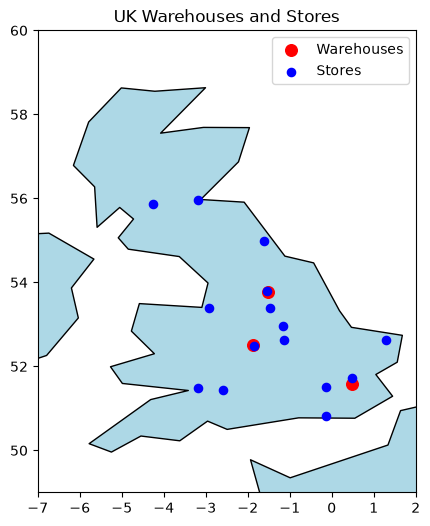

In [12]:
# plot the UK map with warehouses and stores
axis = world_data.plot(color='lightblue', edgecolor='black')
df_geo.plot(ax=axis, color='red', markersize=70, label='Warehouses')
df_geo_stores.plot(ax=axis, color='blue', markersize=35, label='Stores')

# Zoom the map view exclusively to the UK coordinates
axis.set_xlim(-7, 2)   # Longitude (West to East)
axis.set_ylim(49, 60)   # Latitude (South to North)

plt.title('UK Warehouses and Stores')
axis.legend()

fig = plt.gcf()
fig.set_size_inches(9,6)
fig.savefig('matplot.png', dpi = 200)
plt.show()

In [13]:
import pandas as pd
import numpy as np

def haversine_cross(df1, df2, lat_col='latitude', lon_col='longitude', R=6371):
    lat1 = np.radians(df1[lat_col].values)[:, None]   # shape (n1, 1)
    lon1 = np.radians(df1[lon_col].values)[:, None]
    lat2 = np.radians(df2[lat_col].values)[None, :]   # shape (1, n2)
    lon2 = np.radians(df2[lon_col].values)[None, :]

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

dist_matrix = haversine_cross(df_geo, df_stores)

dist_df = pd.DataFrame(
    dist_matrix,
    index=df_geo['name'],
    columns = df_stores['name']
)


In [14]:
dist_df

name,London,Chelmsford,Brighton,Bristol,Birmingham,Leicester,Norwich,Nottingham,Sheffield,Leeds,Liverpool,Newcastle,Cardiff,Edinburgh,Glasgow
name,,,,,,,,,,,,,,,
Basildon Distribution Centre,43.389501,16.235872,95.817357,212.870089,188.978868,160.586913,128.066703,188.171400,239.245172,281.092425,305.451446,401.397097,253.760534,541.890978,567.845585
Birmingham Distribution Centre,164.095509,182.582314,223.244157,128.425268,2.915574,52.309727,214.810239,69.340179,100.187841,144.436716,119.868321,274.056345,145.202295,391.715152,402.760110
Leeds Distribution Centre,268.615474,263.066886,341.122183,268.816990,143.791189,128.825691,226.055114,94.187758,43.619388,3.427067,101.709663,133.784869,278.358076,265.139552,290.969096


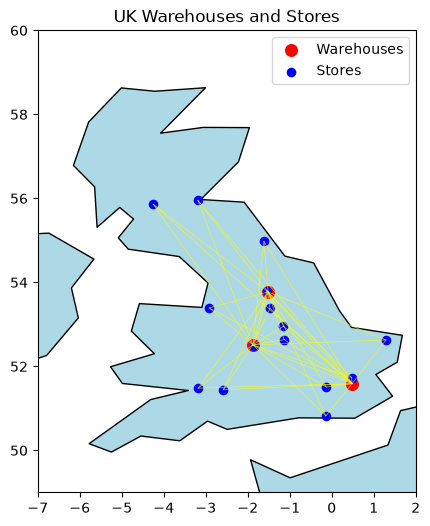

In [15]:
# plot the UK map with warehouses and stores
axis = world_data.plot(color='lightblue', edgecolor='black')
df_geo.plot(ax=axis, color='red', markersize=70, label='Warehouses')
df_geo_stores.plot(ax=axis, color='blue', markersize=35, label='Stores')

# draw a line for every warehouse-store pair
for _, wh in df_geo.iterrows():
    for _, store in df_geo_stores.iterrows():
        axis.plot(
            [wh['longitude'], store['longitude']],
            [wh['latitude'], store['latitude']],
            color='yellow', linewidth=0.5, alpha=0.7, zorder=1
        )

axis.set_xlim(-7, 2)
axis.set_ylim(49, 60)
plt.title('UK Warehouses and Stores')
axis.legend()
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.savefig('matplot.png', dpi=200)
plt.show()

In [16]:
dist_df

name,London,Chelmsford,Brighton,Bristol,Birmingham,Leicester,Norwich,Nottingham,Sheffield,Leeds,Liverpool,Newcastle,Cardiff,Edinburgh,Glasgow
name,,,,,,,,,,,,,,,
Basildon Distribution Centre,43.389501,16.235872,95.817357,212.870089,188.978868,160.586913,128.066703,188.171400,239.245172,281.092425,305.451446,401.397097,253.760534,541.890978,567.845585
Birmingham Distribution Centre,164.095509,182.582314,223.244157,128.425268,2.915574,52.309727,214.810239,69.340179,100.187841,144.436716,119.868321,274.056345,145.202295,391.715152,402.760110
Leeds Distribution Centre,268.615474,263.066886,341.122183,268.816990,143.791189,128.825691,226.055114,94.187758,43.619388,3.427067,101.709663,133.784869,278.358076,265.139552,290.969096


In [17]:
for row_label, row_data in dist_df.iterrows():
   
    print(row_data)
    

name
London         43.389501
Chelmsford     16.235872
Brighton       95.817357
Bristol       212.870089
Birmingham    188.978868
Leicester     160.586913
Norwich       128.066703
Nottingham    188.171400
Sheffield     239.245172
Leeds         281.092425
Liverpool     305.451446
Newcastle     401.397097
Cardiff       253.760534
Edinburgh     541.890978
Glasgow       567.845585
Name: Basildon Distribution Centre, dtype: float64
name
London        164.095509
Chelmsford    182.582314
Brighton      223.244157
Bristol       128.425268
Birmingham      2.915574
Leicester      52.309727
Norwich       214.810239
Nottingham     69.340179
Sheffield     100.187841
Leeds         144.436716
Liverpool     119.868321
Newcastle     274.056345
Cardiff       145.202295
Edinburgh     391.715152
Glasgow       402.760110
Name: Birmingham Distribution Centre, dtype: float64
name
London        268.615474
Chelmsford    263.066886
Brighton      341.122183
Bristol       268.816990
Birmingham    143.791189
Leices

In [18]:
basildon_distance = dist_df.loc['Basildon Distribution Centre']
basildon_df = basildon_distance.to_frame()
basildon_df = basildon_df.rename(columns={'Basildon Distribution Centre': 'distance'})
basildon_df['upper_cost'] = basildon_df['distance'] * 0.55
basildon_df['lower_cost'] = basildon_df['distance'] * 0.35

In [19]:
basildon_df

,distance,upper_cost,lower_cost
name,,,
London,43.389501,23.864225,15.186325
Chelmsford,16.235872,8.929729,5.682555
Brighton,95.817357,52.699546,33.536075
Bristol,212.870089,117.078549,74.504531
Birmingham,188.978868,103.938377,66.142604
Leicester,160.586913,88.322802,56.205419
Norwich,128.066703,70.436686,44.823346
Nottingham,188.171400,103.494270,65.859990
Sheffield,239.245172,131.584845,83.735810


In [32]:
birmingham_distance = dist_df.loc['Birmingham Distribution Centre']
birmingham_df = birmingham_distance.to_frame()
birmingham_df = birmingham_df.rename(columns={'Birmingham Distribution Centre': 'distance'})
birmingham_df['upper_cost'] = birmingham_df['distance'] * 0.55
birmingham_df['lower_cost'] = birmingham_df['distance'] * 0.3


In [33]:
birmingham_df

,distance,upper_cost,lower_cost
name,,,
London,164.095509,90.252530,49.228653
Chelmsford,182.582314,100.420273,54.774694
Brighton,223.244157,122.784287,66.973247
Bristol,128.425268,70.633897,38.527580
Birmingham,2.915574,1.603566,0.874672
Leicester,52.309727,28.770350,15.692918
Norwich,214.810239,118.145632,64.443072
Nottingham,69.340179,38.137099,20.802054
Sheffield,100.187841,55.103312,30.056352


In [22]:
leeds_distance = dist_df.loc['Leeds Distribution Centre']
leeds_df = leeds_distance.to_frame()
leeds_df = leeds_df.rename(columns={'Leeds Distribution Centre': 'distance'})
leeds_df['upper_cost'] = leeds_df['distance'] * 0.55
leeds_df['lower_cost'] = leeds_df['distance'] * 0.35

In [23]:
leeds_df

,distance,upper_cost,lower_cost
name,,,
London,268.615474,147.738511,94.015416
Chelmsford,263.066886,144.686787,92.073410
Brighton,341.122183,187.617201,119.392764
Bristol,268.816990,147.849344,94.085946
Birmingham,143.791189,79.085154,50.326916
Leicester,128.825691,70.854130,45.088992
Norwich,226.055114,124.330313,79.119290
Nottingham,94.187758,51.803267,32.965715
Sheffield,43.619388,23.990664,15.266786


## Standard Form

**Minimise:**

$$
\sum_{i=1}^{3} \sum_{j=1}^{15} c_{ij} x_{ij}
$$

**Subject to:**

$$
\sum_{j=1}^{15} x_{ij} + s_i = \text{capacity}_i
\quad \forall i \in \{1,2,3\} \text{ (warehouses)}
$$

$$
\sum_{i=1}^{3} x_{ij} - e_j = \text{demand}_j
\quad \forall j \in \{1,\ldots,15\} \text{ (stores)}
$$

$$
x_{ij},\, s_i,\, e_j \geq 0
\quad \forall i,j
$$

In [24]:
pip install pulp

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pulp as pl

prob = pl.LpProblem("Warehouse_Transportation", pl.LpMinimize)

In [26]:
warehouses = df_geo['name'].tolist()
stores = df_geo_stores['name'].tolist()

In [27]:
warehouses, stores

(['Basildon Distribution Centre',
  'Birmingham Distribution Centre',
  'Leeds Distribution Centre'],
 ['London',
  'Chelmsford',
  'Brighton',
  'Bristol',
  'Birmingham',
  'Leicester',
  'Norwich',
  'Nottingham',
  'Sheffield',
  'Leeds',
  'Liverpool',
  'Newcastle',
  'Cardiff',
  'Edinburgh',
  'Glasgow'])

In [28]:
x = pl.LpVariable.dicts("ship", (warehouses,stores), lowBound=0)

In [29]:
prob 

{'Basildon Distribution Centre': {'London': ship_Basildon_Distribution_Centre_London,
  'Chelmsford': ship_Basildon_Distribution_Centre_Chelmsford,
  'Brighton': ship_Basildon_Distribution_Centre_Brighton,
  'Bristol': ship_Basildon_Distribution_Centre_Bristol,
  'Birmingham': ship_Basildon_Distribution_Centre_Birmingham,
  'Leicester': ship_Basildon_Distribution_Centre_Leicester,
  'Norwich': ship_Basildon_Distribution_Centre_Norwich,
  'Nottingham': ship_Basildon_Distribution_Centre_Nottingham,
  'Sheffield': ship_Basildon_Distribution_Centre_Sheffield,
  'Leeds': ship_Basildon_Distribution_Centre_Leeds,
  'Liverpool': ship_Basildon_Distribution_Centre_Liverpool,
  'Newcastle': ship_Basildon_Distribution_Centre_Newcastle,
  'Cardiff': ship_Basildon_Distribution_Centre_Cardiff,
  'Edinburgh': ship_Basildon_Distribution_Centre_Edinburgh,
  'Glasgow': ship_Basildon_Distribution_Centre_Glasgow},
 'Birmingham Distribution Centre': {'London': ship_Birmingham_Distribution_Centre_London,
  '

In [34]:
cost_df = pd.concat(
    [basildon_df, birmingham_df, leeds_df],
    keys=['Basildon Distribution Centre', 'Birmingham Distribution Centre', 'Leeds Distribution Centre']
)

In [35]:
cost_df

distance  upper_cost  lower_cost
                               name                                          
Basildon Distribution Centre   London       43.389501   23.864225   15.186325
                               Chelmsford   16.235872    8.929729    5.682555
                               Brighton     95.817357   52.699546   33.536075
                               Bristol     212.870089  117.078549   74.504531
                               Birmingham  188.978868  103.938377   66.142604
                               Leicester   160.586913   88.322802   56.205419
                               Norwich     128.066703   70.436686   44.823346
                               Nottingham  188.171400  103.494270   65.859990
                               Sheffield   239.245172  131.584845   83.735810
                               Leeds       281.092425  154.600834   98.382349
                               Liverpool   305.451446  167.998295  106.908006
                               Newcastle   401.397097  220.768403  140.488984
                               Cardiff     253.760534  139.568293   88.816187
                               Edinburgh   541.890978  298.040038  189.661842
                               Glasgow     567.845585  312.315072  198.745955
Birmingham Distribution Centre London      164.095509   90.252530   49.228653
                               Chelmsford  182.582314  100.420273   54.774694
                               Brighton    223.244157  122.784287   66.973247
                               Bristol     128.425268   70.633897   38.527580
                               Birmingham    2.915574    1.603566    0.874672
                               Leicester    52.309727   28.770350   15.692918
                               Norwich     214.810239  118.145632   64.443072
                               Nottingham   69.340179   38.137099   20.802054
                               Sheffield   100.187841   55.103312   30.056352
                               Leeds       144.436716   79.440194   43.331015
                               Liverpool   119.868321   65.927576   35.960496
                               Newcastle   274.056345  150.730989   82.216903
                               Cardiff     145.202295   79.861262   43.560688
                               Edinburgh   391.715152  215.443334  117.514546
                               Glasgow     402.760110  221.518060  120.828033
Leeds Distribution Centre      London      268.615474  147.738511   94.015416
                               Chelmsford  263.066886  144.686787   92.073410
                               Brighton    341.122183  187.617201  119.392764
                               Bristol     268.816990  147.849344   94.085946
                               Birmingham  143.791189   79.085154   50.326916
                               Leicester   128.825691   70.854130   45.088992
                               Norwich     226.055114  124.330313   79.119290
                               Nottingham   94.187758   51.803267   32.965715
                               Sheffield    43.619388   23.990664   15.266786
                               Leeds         3.427067    1.884887    1.199473
                               Liverpool   101.709663   55.940315   35.598382
                               Newcastle   133.784869   73.581678   46.824704
                               Cardiff     278.358076  153.096942   97.425327
                               Edinburgh   265.139552  145.826753   92.798843
                               Glasgow     290.969096  160.033003  101.839184

In [36]:
cost_df.loc[('Birmingham Distribution Centre', 'Leicester'), 'upper_cost']

np.float64(28.77034964010663)

In [38]:
prob += pl.lpSum([
    cost_df.loc[(i, j), 'upper_cost'] * x[i][j]
    for i in warehouses
    for j in stores
]), "Total Upper Cost"

In [40]:
for i in warehouses:

    capacity_i = df_geo[df_geo['name'] == i]['capacity'].values[0]

    prob += (
        pl.lpSum([x[i][j] for j in stores]) <= capacity_i,
        f"Capacity_{i}"
    )

In [41]:
for j in stores:

    demand_j = df_geo_stores[df_geo_stores['name'] == j]['demand'].values[0]


    prob += (
        pl.lpSum([x[i][j] for i in warehouses]) >= demand_j,
        f"Demand_{j}"
    )

In [42]:
prob.writeLP("Warehouse_Optimisation.lp")

[ship_Basildon_Distribution_Centre_Birmingham,
 ship_Basildon_Distribution_Centre_Brighton,
 ship_Basildon_Distribution_Centre_Bristol,
 ship_Basildon_Distribution_Centre_Cardiff,
 ship_Basildon_Distribution_Centre_Chelmsford,
 ship_Basildon_Distribution_Centre_Edinburgh,
 ship_Basildon_Distribution_Centre_Glasgow,
 ship_Basildon_Distribution_Centre_Leeds,
 ship_Basildon_Distribution_Centre_Leicester,
 ship_Basildon_Distribution_Centre_Liverpool,
 ship_Basildon_Distribution_Centre_London,
 ship_Basildon_Distribution_Centre_Newcastle,
 ship_Basildon_Distribution_Centre_Norwich,
 ship_Basildon_Distribution_Centre_Nottingham,
 ship_Basildon_Distribution_Centre_Sheffield,
 ship_Birmingham_Distribution_Centre_Birmingham,
 ship_Birmingham_Distribution_Centre_Brighton,
 ship_Birmingham_Distribution_Centre_Bristol,
 ship_Birmingham_Distribution_Centre_Cardiff,
 ship_Birmingham_Distribution_Centre_Chelmsford,
 ship_Birmingham_Distribution_Centre_Edinburgh,
 ship_Birmingham_Distribution_Centre_G

In [43]:
prob.solve()

1

In [44]:
print("Status:", pl.LpStatus[prob.status])

Status: Optimal


In [45]:
for v in prob.variables():
    print(v.name, "=", v.varValue)

ship_Basildon_Distribution_Centre_Birmingham = 0.0
ship_Basildon_Distribution_Centre_Brighton = 500.0
ship_Basildon_Distribution_Centre_Bristol = 0.0
ship_Basildon_Distribution_Centre_Cardiff = 0.0
ship_Basildon_Distribution_Centre_Chelmsford = 400.0
ship_Basildon_Distribution_Centre_Edinburgh = 0.0
ship_Basildon_Distribution_Centre_Glasgow = 0.0
ship_Basildon_Distribution_Centre_Leeds = 0.0
ship_Basildon_Distribution_Centre_Leicester = 0.0
ship_Basildon_Distribution_Centre_Liverpool = 0.0
ship_Basildon_Distribution_Centre_London = 1800.0
ship_Basildon_Distribution_Centre_Newcastle = 0.0
ship_Basildon_Distribution_Centre_Norwich = 450.0
ship_Basildon_Distribution_Centre_Nottingham = 0.0
ship_Basildon_Distribution_Centre_Sheffield = 0.0
ship_Birmingham_Distribution_Centre_Birmingham = 1300.0
ship_Birmingham_Distribution_Centre_Brighton = 0.0
ship_Birmingham_Distribution_Centre_Bristol = 800.0
ship_Birmingham_Distribution_Centre_Cardiff = 550.0
ship_Birmingham_Distribution_Centre_Chelmsf

In [48]:
print("The total cost of shipping is", pl.value(prob.objective))

The total cost of shipping is 596198.2086853484
